<a href="https://colab.research.google.com/github/tshabalalasibongile/Fraud-Detection/blob/main/FRAUD_DETECTION_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Dataset Inspection & Initial Validation**

**Overview**

**Records:** ~284,000 transactions

**Features:** Transaction-level variables (anonymised)

**Target Variable:** Class (0 = Normal, 1 = Fraud)

This dataset represents real-world credit card transactions used to detect fraudulent activity.

**Target Distribution**

**Fraudulent Transactions:** ~0.17%

**Normal Transactions:** ~99.83%

This represents extreme class imbalance, a key challenge in fraud detection.

**Data Quality Observations**

**1. No Missing Values**
Dataset is fully clean and ready for modelling

**2. Highly Imbalanced Target**
Requires careful evaluation using appropriate metrics

**Initial Analytical Conclusion**

**Dataset is suitable for:**

Fraud detection modelling

Anomaly detection

Transaction risk scoring

**2. Data Preparation**

**Objective**

Prepare transaction data for modelling while preserving patterns critical for fraud detection.

**Preparation Steps**

Feature scaling applied using StandardScaler

Target variable separated

Stratified train-test split used to preserve class distribution

**Data Quality Checks**

Class distribution validation

Feature consistency checks

**Business Outcome**

**Ensures:**

Reliable fraud modelling

Accurate representation of rare events

**3. Exploratory Data Analysis (EDA)**

**Objective**

Understand fraud patterns and identify characteristics that distinguish fraudulent transactions.

**Key Insights**

**1. Class Imbalance**
Fraud events are extremely rare

**2. Transaction Amount**
Distribution varies across normal vs fraudulent transactions

**3. Detection Challenge**
Traditional accuracy metrics are misleading

Analytical Conclusion

**Fraud detection requires:**

Specialised evaluation metrics
Focus on minority class detection

**4. Fraud Detection Modelling**

**Objective**

Develop models to detect fraudulent transactions while balancing detection rate and false positives.

**Modelling Approach**

**Models used:**

Logistic Regression (baseline)

Random Forest (enhanced detection)

**Evaluation Metrics**

ROC AUC

Precision

Recall

Confusion Matrix

**Performance Insights**

High recall is critical → capture fraud cases

Precision balances customer experience (reducing false alerts)

**Business Interpretation**
Models can identify suspicious transactions effectively

**Trade-off required between:**

Fraud detection

Customer friction

**5. Business Insights & Application**

**Key Learnings**
Fraud detection is a high-risk, high-impact problem

Missing fraud cases is more costly than false positives

**Use Cases**

**1. Real-Time Fraud Detection**
Flag suspicious transactions instantly

**2. Risk Scoring Systems**
Assign fraud probability to transactions

**3. Fraud Prevention Strategy**
Improve monitoring and controls

**Key Business Insight**

Effective fraud detection requires balancing detection sensitivity (recall) with operational efficiency and customer experience.

**1. IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


**2. LOAD DATA**

In [2]:
df = pd.read_csv('creditcard.csv')

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

**3. DATA UNDERSTANDING**

In [3]:
# Check class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())

fraud_rate = df['Class'].mean()
print(f"\nFraud Rate: {fraud_rate:.4f}")


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.0017


**4. DATA CLEANING**

In [4]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Dataset is already clean (no missing values)


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


**5. EXPLORATORY DATA ANALYSIS**

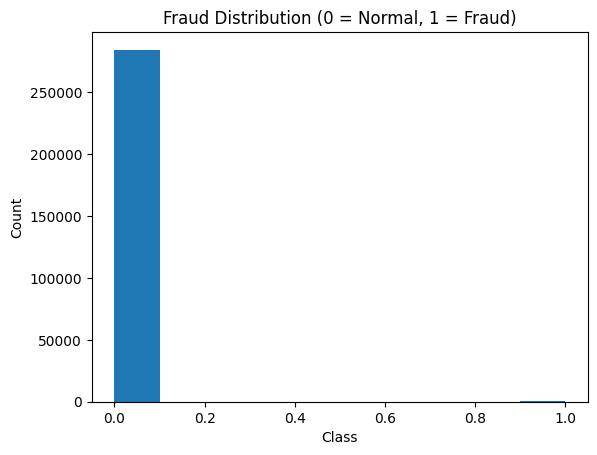

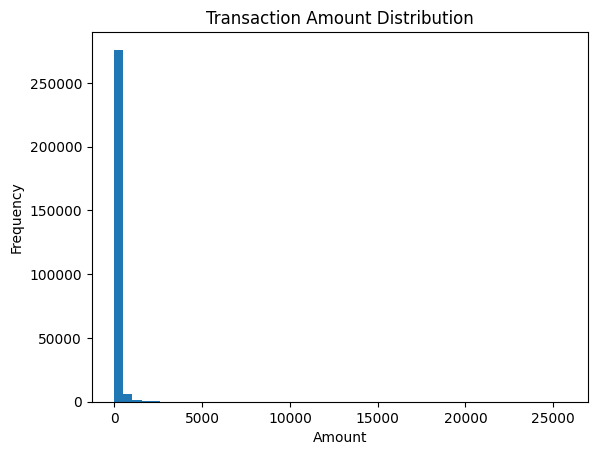

In [5]:
# Fraud vs Non-Fraud
plt.figure()
plt.hist(df['Class'])
plt.title('Fraud Distribution (0 = Normal, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Transaction Amount Distribution
plt.figure()
plt.hist(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

**6. FEATURE ENGINEERING**

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**7. TRAIN-TEST SPLIT**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


**8. MODEL BUILDING**

In [8]:
# Logistic Regression (baseline)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Random Forest (stronger model)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**9. MODEL EVALUATION FUNCTION**

In [9]:
def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {model_name} ===")
    print("AUC:", roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=model_name)

**10. EVALUATE MODELS**


=== Logistic Regression ===
AUC: 0.9599474004570878

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


=== Random Forest ===
AUC: 0.9630264440469491

Confusion Matrix:
[[56859     5]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



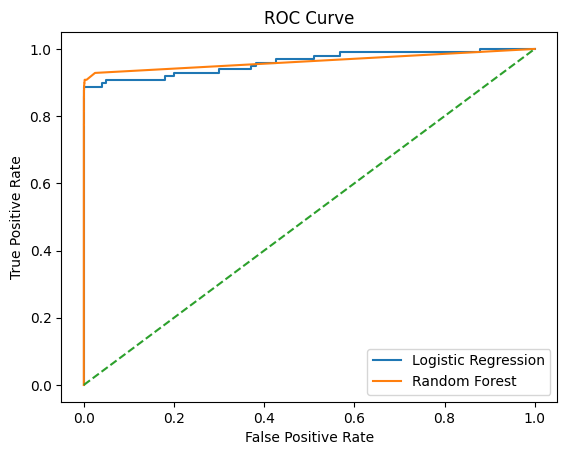

In [10]:
plt.figure()

evaluate_model(log_model, "Logistic Regression")
evaluate_model(rf_model, "Random Forest")

plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**11. BUSINESS INSIGHTS**

In [13]:
print("- Fraud is highly imbalanced (very rare events)")
print("- Models can detect suspicious transactions effectively")
print("- Recall is critical to capture fraudulent transactions")
print("- Precision helps reduce false positives (customer friction)")

- Fraud is highly imbalanced (very rare events)
- Models can detect suspicious transactions effectively
- Recall is critical to capture fraudulent transactions
- Precision helps reduce false positives (customer friction)
